# **1. Introduction**
## 1.1 Background and Context
### The dataset provided in this project contains information on students from various tutorial groups such as their Names, Gender, School, and CGPA. 
### Our objective is to design and implement an algorithm that will automatically form diverse student teams of 5 based on these attributes. The challenge is to ensure that the teams remain balanced and diverse across all tutorial groups while handling uneven distributions and potential data inconsistencies.

## 1.2 Overview
### - To clean and preprocess the dataset for use in team formation.
### - To analyze patterns in gender, CGPA, and school distributions.
### - To design an algorithm that forms diverse groups fairly.
### - To evaluate how well the algorithm maintains diversity across all teams.

# **2. Data Overview**
## 2.1 Pseudocode/ Flowchart

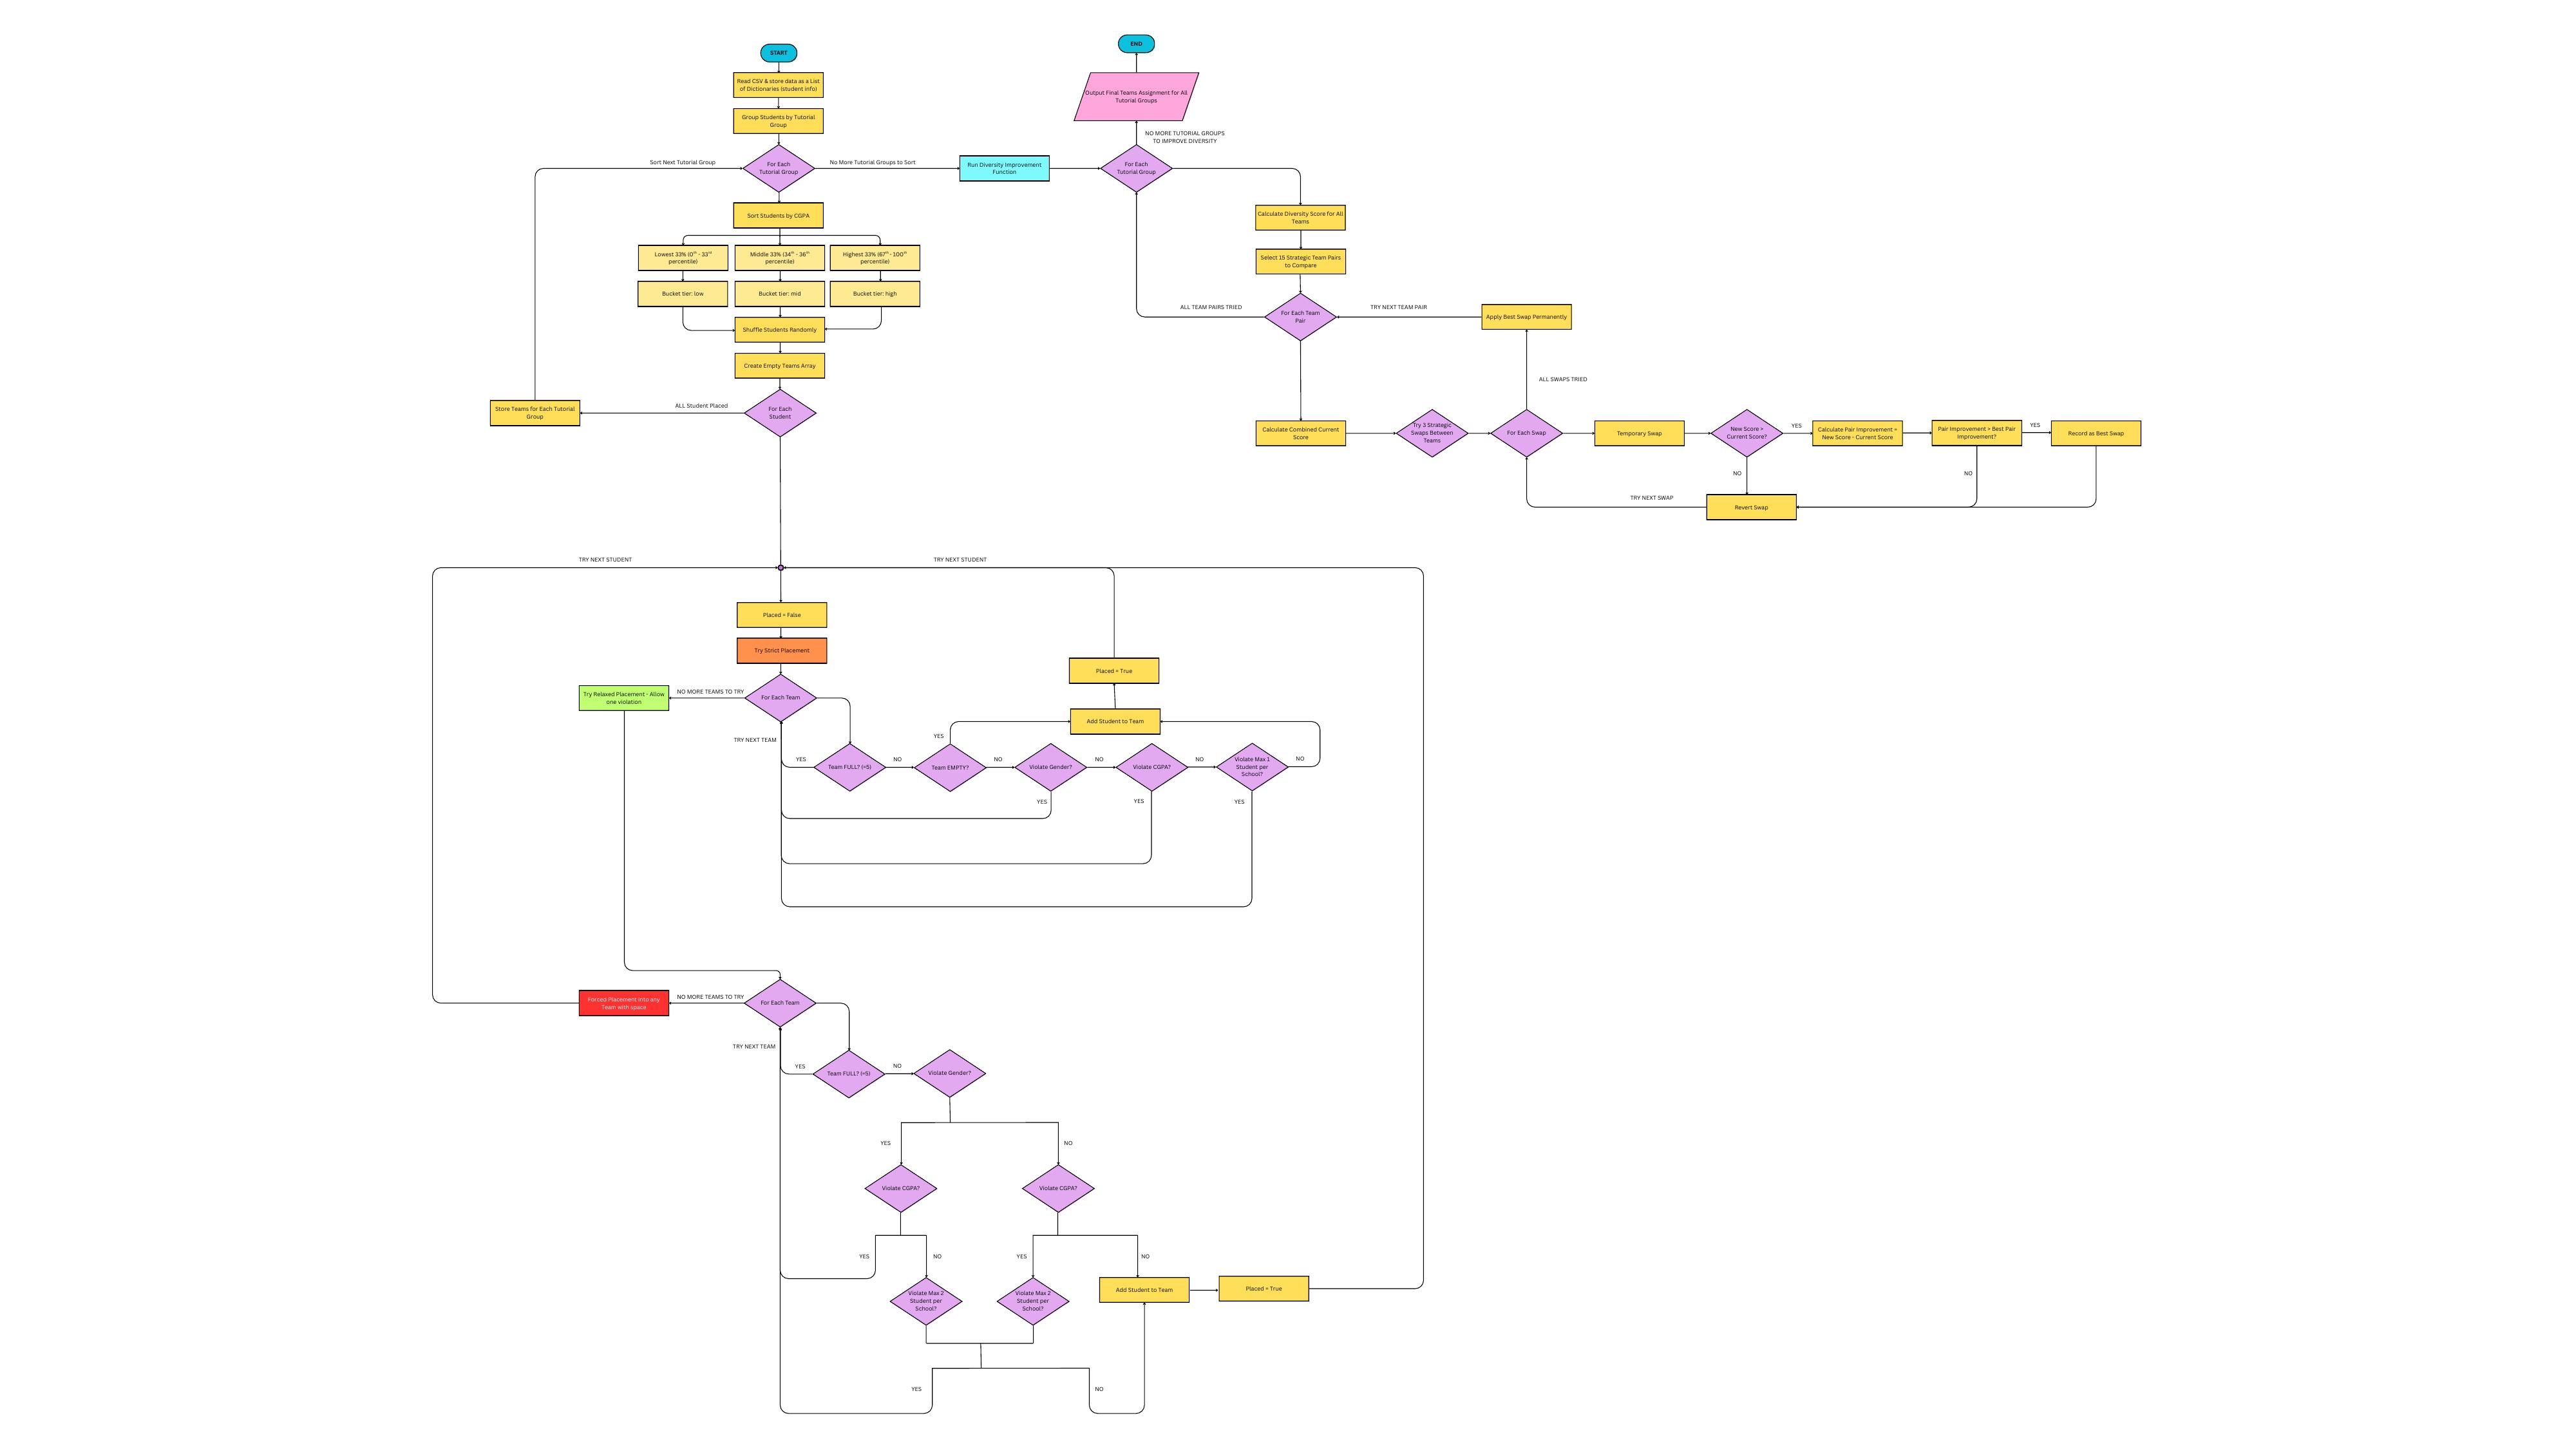

## 2.2 Dataset Description (fields, size, tutorial groups)

In [17]:
if data:
# - Total number of students
    total_students = len(data)

# - Unique Identifiers (Name and Student ID)
 # We can confirm they are unique by checking the count of unique values
num_unique_ids = len(set(student['student_id'] for student in data))
num_unique_names = len(set(student['name'] for student in data))

# - Tutorial group information
all_groups = [student['tutorial_group'] for student in data]
unique_groups = sorted(list(set(all_groups)))
num_unique_groups = len(unique_groups)

# - Gender information
gender_counts = Counter(student['gender'] for student in data)

# - Tutorial group information
all_groups = [student['tutorial_group'] for student in data]
unique_groups = sorted(list(set(all_groups)))
num_unique_groups = len(unique_groups)

# - School information
all_schools = [student['school'] for student in data]
unique_schools = sorted(list(set(all_schools)))
num_unique_schools = len(unique_schools)

# - CGPA information
all_cgpas = [student['cgpa'] for student in data]
min_cgpa = min(all_cgpas)
max_cgpa = max(all_cgpas)
average_cgpa = sum(all_cgpas) / total_students

In [22]:
print("\n# Dataset Description")
print("-" * 25) # This creates a separator line for a neat look

# 1. Total number of entries
print(f"- The dataset has a total of {total_students} entries of students.")

# 2. School information
print(f"- There are {num_unique_schools} unique schools/faculties in this dataset:")
# This loop prints the school names in a clean list format if there are many,
# otherwise it prints them on one line.
print(f"  {', '.join(unique_schools)}") 

# 3. Tutorial group information
print(f"- There are {num_unique_groups} unique tutorial groups in this dataset.")

# 4. Gender distribution
print(f"- The gender distribution is as follows:")
# The 'for' loop must be at the same indentation level as the print statement above it.
for gender, count in gender_counts.items():
    # The print statement inside the loop must be indented further.
    print(f"  - {gender}: {count} students")

# 5. CGPA information
print(f"- The CGPA of the students ranges from {min_cgpa:.2f} to {max_cgpa:.2f}, with an average of {average_cgpa:.2f}.")

# 6. Name + student ID information and verification
print("- Each student is uniquely identified by their 'Name' and 'Student ID'.")
if num_unique_ids == total_students:
    print("  (Verification: All Student IDs are unique.)")
else:
    print("  (Warning: Duplicate Student IDs were found in the data.)")

# This 'else' statement is now correctly placed. It belongs to the 'if data:' check
# at the very beginning of the analysis. It will only run if the CSV file was not found.
# else:
#     print("\nCould not generate description because no data was loaded.")



# Dataset Description
-------------------------
- The dataset has a total of 6000 entries of students.
- There are 18 unique schools/faculties in this dataset:
  ADM, ASE, CCDS, CCEB, CEE, CoB (NBS), CoE, EEE, HASS, LKCMedicine, MAE, MSE, NIE, SBS, SPMS, SSS, SoH, WKW SCI
- There are 120 unique tutorial groups in this dataset.
- The gender distribution is as follows:
  - Male: 2759 students
  - Female: 3241 students
- The CGPA of the students ranges from 3.70 to 4.97, with an average of 4.09.
- Each student is uniquely identified by their 'Name' and 'Student ID'.
  (Verification: All Student IDs are unique.)


## 2.3 Data Cleaning/ Preprocessing 

### The first step in our preprocessing of the data involves taking the raw student data from the records.csv file. Using Python's built-in csv library, each row of the file is read and transformed into a dictionary. This process that the data is structured by mapping column headers like 'Name' and 'CGPA' to their corresponding values for each student. The result is a list of dictionaries where each dictionary represents a single student's complete record. At this stage, all data is stored as raw text strings, which will be further processed in subsequent steps.

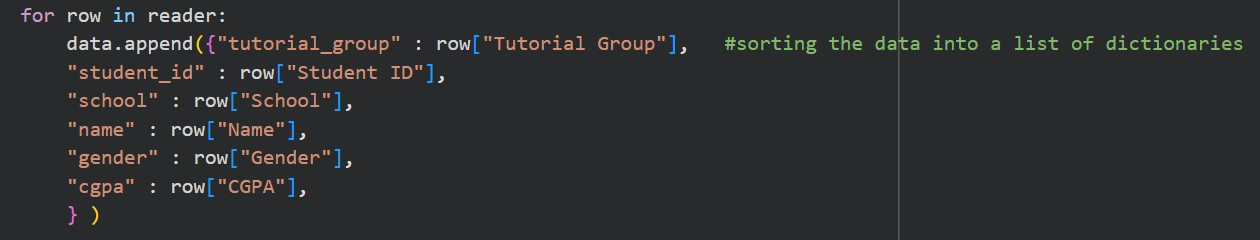

### To facilitate group-based analysis, the flat list of student data is restructured into a dictionary. This dictionary, named tutorial_groups, uses the unique tutorial group name as its key. The value for each key is a list containing the records of all students belonging to that group. During this process, a data cleaning step is applied: the .strip() method is used on each tutorial group name to remove any accidental whitespace, ensuring that groups are categorized consistently. This ensures that there will be no issue in the subsequent step of relative performance tiering.

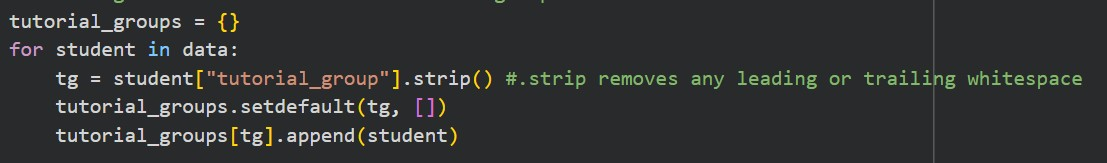

### The final preprocessing step we did was to create a categorical feature named 'bucket' to classify each student's academic performance. This classification is not based on absolute CGPA scores, but rather on a student's relative rank within their own tutorial group. For each group, the list of students is sorted by CGPA. This sorted list is then sectioned into three tiers: the bottom third are assigned to the 'low' bucket, the middle third to the 'mid' bucket, and the top third to the 'high' bucket. Each student's record is then updated with this new 'bucket' key. This process allows us to analyse the performance patterns and group dynamics of the data easier.

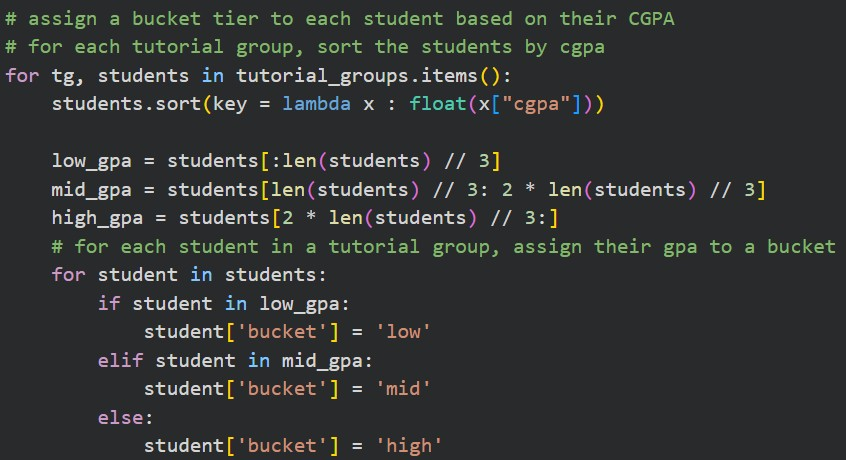

In [14]:
import csv
import random
data = []
file_path = r"C:\Users\megan\Dropbox\My PC (LAPTOP-DH97NNK3)\Desktop\records.csv"
with open(file_path, newline='', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        data.append({
            "tutorial_group": row["Tutorial Group"].strip(),
            "student_id": row["Student ID"].strip(),
            "school": row["School"].strip(),
            "name": row["Name"].strip(),
            "gender": row["Gender"].strip(),
            "cgpa": float(row["CGPA"])  # convert to float for comparison
        })

for entry in data:
    print(entry)

{'tutorial_group': 'G-1', 'student_id': '5002', 'school': 'CCDS', 'name': 'Aarav Singh', 'gender': 'Male', 'cgpa': 4.02}
{'tutorial_group': 'G-1', 'student_id': '3838', 'school': 'EEE', 'name': 'Aarti Nair', 'gender': 'Female', 'cgpa': 4.05}
{'tutorial_group': 'G-1', 'student_id': '2091', 'school': 'EEE', 'name': 'Adlan Bin Rahman', 'gender': 'Male', 'cgpa': 4.2}
{'tutorial_group': 'G-1', 'student_id': '288', 'school': 'CoB (NBS)', 'name': 'Ajay Verma', 'gender': 'Male', 'cgpa': 4.01}
{'tutorial_group': 'G-1', 'student_id': '4479', 'school': 'CCDS', 'name': 'Amelia Kim', 'gender': 'Female', 'cgpa': 4.11}
{'tutorial_group': 'G-1', 'student_id': '5708', 'school': 'SoH', 'name': 'Ananya Ramesh', 'gender': 'Male', 'cgpa': 4.2}
{'tutorial_group': 'G-1', 'student_id': '4563', 'school': 'WKW SCI', 'name': 'Anjali Patel', 'gender': 'Female', 'cgpa': 4.01}
{'tutorial_group': 'G-1', 'student_id': '3989', 'school': 'WKW SCI', 'name': 'Anthony Liu', 'gender': 'Male', 'cgpa': 4.15}
{'tutorial_group

# **3. Data Analysis**
### This section explores the patterns, distributions and key characteristics of the student records dataset. The focus of this section is to understand the content of the data through summarised statistics and visualizations generated. Our analysis is structured around three main categories: gender, CGPA, and school.

## 3.1 Gender Distribution

In [10]:
import sys
!"{sys.executable}" -m pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\megan\Dropbox\My PC (LAPTOP-DH97NNK3)\Desktop\sc1003 jupyter\NEW-VENV\Scripts\python.exe -m pip install --upgrade pip


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

Successfully loaded 6000 student records.

--- Generating Visual 1: Gender Distribution ---


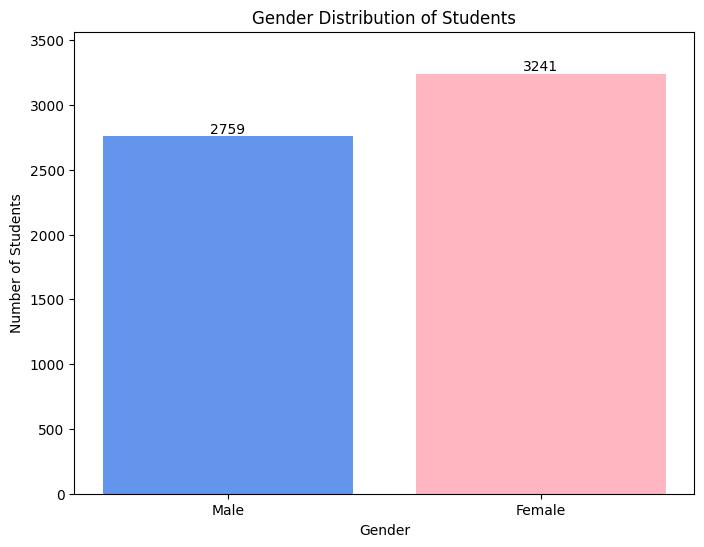

In [2]:
# -------------------- Part 1: Imports --------------------
import csv
import matplotlib.pyplot as plt
from collections import Counter

# -------------------- Part 2: Load Your Data --------------------
data = []

# IMPORTANT: This path has been updated to a simpler location.
# Make sure your file is actually at this location (e.g., your Desktop).
file_path = r"C:\Users\megan\Desktop\records.csv"

try:
    with open(file_path, mode='r', newline='', encoding='utf-8') as file:
        reader = csv.DictReader(file)
        for row in reader:
            data.append({
                "tutorial_group": row["Tutorial Group"].strip(),
                "student_id": row["Student ID"].strip(),
                "school": row["School"].strip(),
                "name": row["Name"].strip(),
                "gender": row["Gender"].strip(),
                "cgpa": float(row["CGPA"])
            })
    print(f"Successfully loaded {len(data)} student records.")
except FileNotFoundError:
    print(f"ERROR: The file was not found at the path: {file_path}")
    print("Please move your 'records.csv' file to your Desktop and try again.")
    data = [] # Ensure data is empty if file is not found

# -------------------- Part 3: Create the Visualizations --------------------

if data:
    # --- VISUAL 1: Gender Distribution ---
    print("\n--- Generating Visual 1: Gender Distribution ---")
    gender_counts = Counter(student['gender'] for student in data)
    genders = list(gender_counts.keys())
    counts = list(gender_counts.values())

    plt.figure(figsize=(8, 6))
    bars = plt.bar(genders, counts, color=['#6495ED', '#FFB6C1'])
    plt.title('Gender Distribution of Students')
    plt.xlabel('Gender')
    plt.ylabel('Number of Students')
    plt.ylim(0, max(counts) * 1.1)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')
    plt.show()
   

### This distribution is to understand the gender balance of the student population in the dataset.

### We generated a bar chart to display the total count of male and female students. The analysis of the dataset shows that the gender distribution is almost balanced with:
### - Total number of students: 6000
### - Male Students: 2759
### - Female Students: 3241

### This shows that there is no significant gender skew in the overall population represented in the dataset.

## 3.2 CGPA Distribution 


--- Generating Visual 2: CGPA Distribution ---


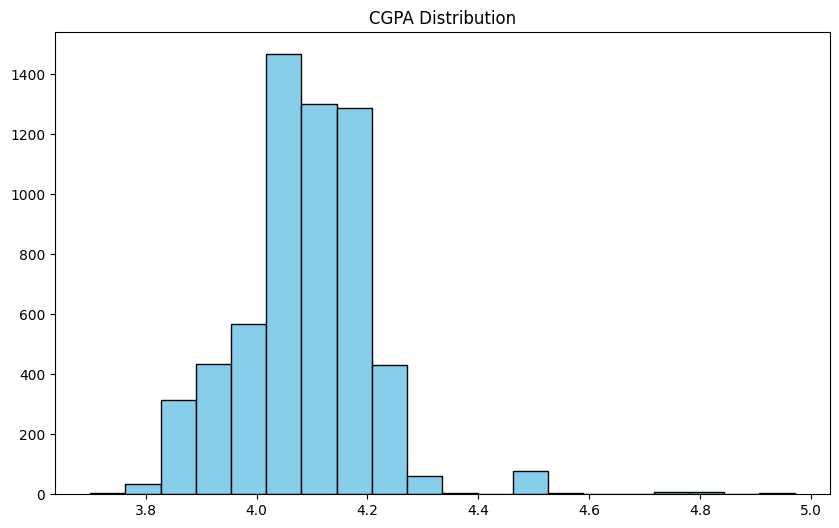

In [5]:
# --- VISUAL 2: CGPA Distribution ---
print("\n--- Generating Visual 2: CGPA Distribution ---")
cgpas = [student['cgpa'] for student in data]
plt.figure(figsize=(10, 6))
plt.hist(cgpas, bins=20, edgecolor='black', color='skyblue')
plt.title('CGPA Distribution')
# ... (rest of your plotting code)
plt.show()

### This distribution analyses the overall academic performance of the students by examining the distribution of their CGPA.

### We used a histogram to show the frequency of students across different CGPA ranges. From the histogram we can see that:

In [23]:
if not data:
    print("The 'data' list is empty. Please load the data from your CSV file first.")
else:
    # --- 1. Extract all CGPA values into a simple list ---
    # This list comprehension efficiently creates a new list containing only the CGPA values.
    all_cgpas = [student['cgpa'] for student in data]

    # --- 2. Calculate the statistics using Python's built-in functions ---
    
    # Find the minimum value in the list
    min_cgpa = min(all_cgpas)
    
    # Find the maximum value in the list
    max_cgpa = max(all_cgpas)
    
    # Calculate the average
    total_students = len(all_cgpas)
    average_cgpa = sum(all_cgpas) / total_students

    # --- 3. Print the results in a clean, formatted report ---
    print("--- CGPA Summary Statistics ---")
    # The ':.2f' inside the f-string formats the numbers to two decimal places.
    print(f"Minimum CGPA: {min_cgpa:.2f}")
    print(f"Maximum CGPA: {max_cgpa:.2f}")
    print(f"Average CGPA: {average_cgpa:.2f}")

--- CGPA Summary Statistics ---
Minimum CGPA: 3.70
Maximum CGPA: 4.97
Average CGPA: 4.09


### The histogram shows that there is a left-skewed distribution as there is a significant number of students clustered in the higher CGPA range between 4.0 and 4.3. The number of students decrease as CGPA decreases and increases with very few students getting a CGPA of 3.8 and lower and a few students who received 4.4 to 5.0.

### This strongly suggests that the student population captured in this dataset is on average, high-achieving. The concentration of high CGPAs indicates that there is a strong academic standard across the cohort.

## 3.3 School/ Faculty Distribution


--- Generating Visual 3: School/Faculty Distribution ---


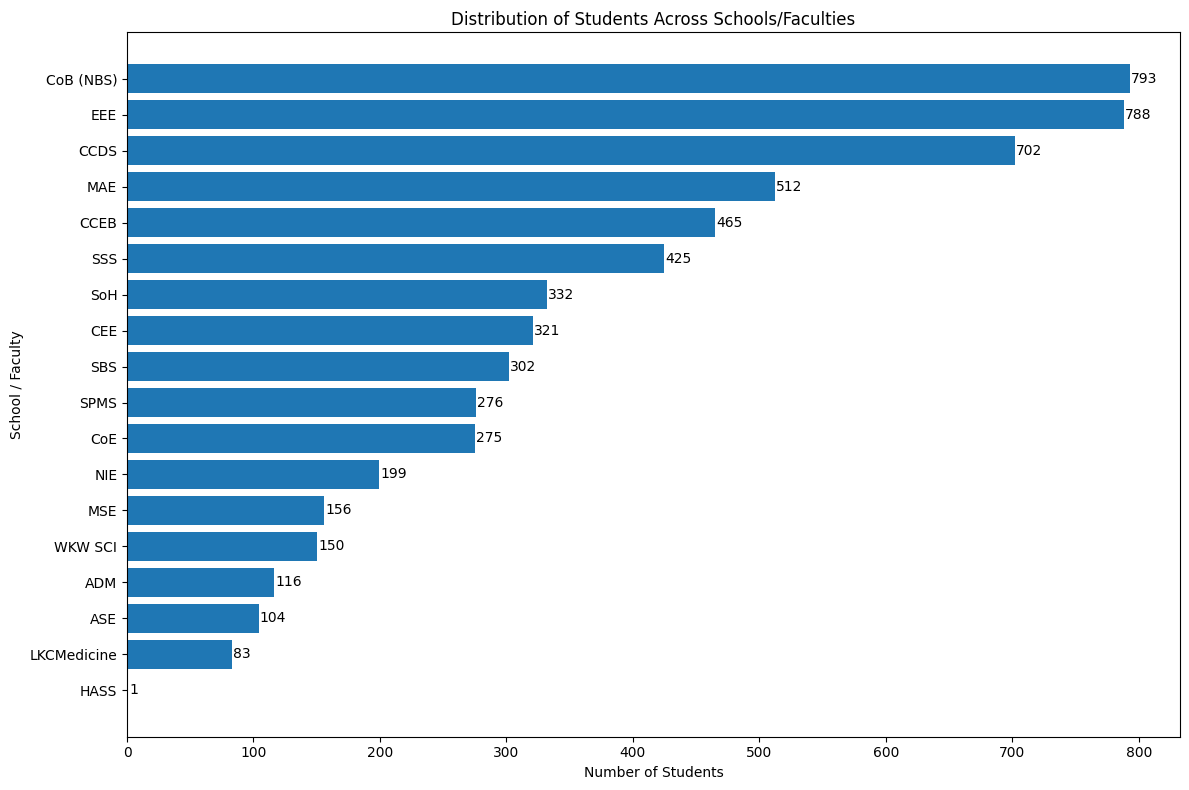

In [7]:
# --- VISUAL 3: School/Faculty Distribution ---
print("\n--- Generating Visual 3: School/Faculty Distribution ---")
school_counts = Counter(student['school'] for student in data)
sorted_schools = school_counts.most_common()
school_names = [item[0] for item in sorted_schools]
student_counts = [item[1] for item in sorted_schools]
    
school_names.reverse()
student_counts.reverse()

plt.figure(figsize=(12, 8))
bars = plt.barh(school_names, student_counts)
plt.title('Distribution of Students Across Schools/Faculties')
plt.xlabel('Number of Students')
plt.ylabel('School / Faculty')
    
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center')
    
plt.tight_layout()
plt.show()

### This distribution shows how students are distributed across the various schools. 

### We used a horizontal bar chart to compare the number of students enrolled in each school with the faculties sorted from most to least populated for clarity.

### The bar chart shows that there is a significant variation in enrollment numbers across 18 schools. The top three most populated schools being:
### 1. CoB (NBS): 793 students
### 2. EEE: 788 students
### 3. CCDS: 702 students

### However, faculties such as LKCMedicine (83 students) and HASS (1 student) have considerably lower enrollment. This distribution highlights the relative scale of the different academic schools. The high enrollment in technology and business oriented schools like NBS and EEE reflect the current industry demand and student interest in these fields. 


## 3.4 Exploring Relationships (Further Analysis)
### 3.4.1 CGPA Distribution by School 
#### This plot is to compare the distribution of CGPA scores across the different schools. 

--- Generating Visual 5: CGPA Distribution by School ---


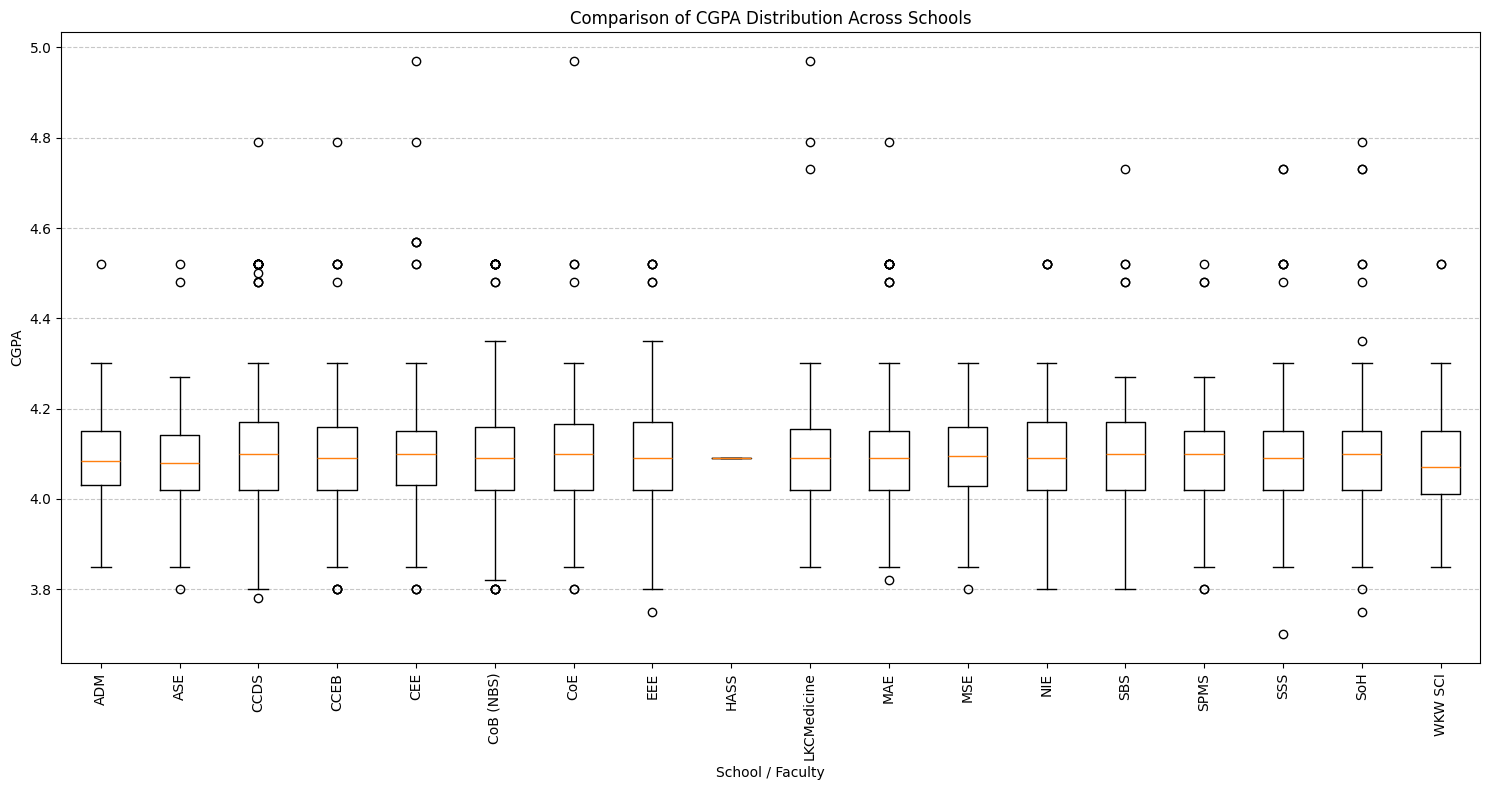

In [24]:
# VISUAL 5: CGPA Distribution by School (Box Plot)
# ==============================================================================
import matplotlib.pyplot as plt
from collections import defaultdict

# This code assumes the 'data' variable is already loaded in memory.

print("--- Generating Visual 5: CGPA Distribution by School ---")

if not data:
    print("The 'data' list is empty. Please load data first.")
else:
    # --- 1. Restructure the data: Group CGPAs by school ---
    # We use defaultdict to easily append to lists without checking if the key exists.
    school_cgpas = defaultdict(list)
    for student in data:
        school_cgpas[student['school']].append(student['cgpa'])
        
    # Sort the schools by name for a consistent order
    sorted_school_names = sorted(school_cgpas.keys())
    
    # Create a list of lists of CGPAs, in the same sorted order
    sorted_cgpa_data = [school_cgpas[school] for school in sorted_school_names]

    # --- 2. Create the Box Plot ---
    plt.figure(figsize=(15, 8)) # A wider figure is needed for many schools
    plt.boxplot(sorted_cgpa_data)

    # --- 3. Add Titles and Labels ---
    plt.title('Comparison of CGPA Distribution Across Schools')
    plt.ylabel('CGPA')
    plt.xlabel('School / Faculty')
    
    # Set the x-axis labels to be the school names and rotate them for readability
    plt.xticks(ticks=range(1, len(sorted_school_names) + 1), labels=sorted_school_names, rotation=90)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()

#### The box plot analysis provides a comparative overview of academic performance across the different schools. A key observation is that while the median CGPA (indicated by the line inside each box) is consistently high across most faculties, generally clustering around 4.0 to 4.2, there are subtle but important differences in score distribution. For instance, faculties like CoE exhibit a slightly higher median, suggesting a concentration of top-performing students. 

#### In contrast, the interquartile range (the height of the boxes) for schools such as CoB(NBS) and EEE is wider than that of ASE, indicating a greater diversity in academic performance among its students. Furthermore, the presence of outliers (individual dots) in certain faculties highlights students who are performing exceptionally above or below their peers within the same program. 

#### Overall, while the entire student population is high-achieving, this visualization effectively breaks down the performance landscape, revealing which faculties have a more uniform student body versus those with a broader range of academic outcomes.

### 3.4.2 Gender Distribution within Schools
#### This distribution shows the number of male and female students in each school. 


--- Generating Visual 6: Gender Distribution within Schools ---


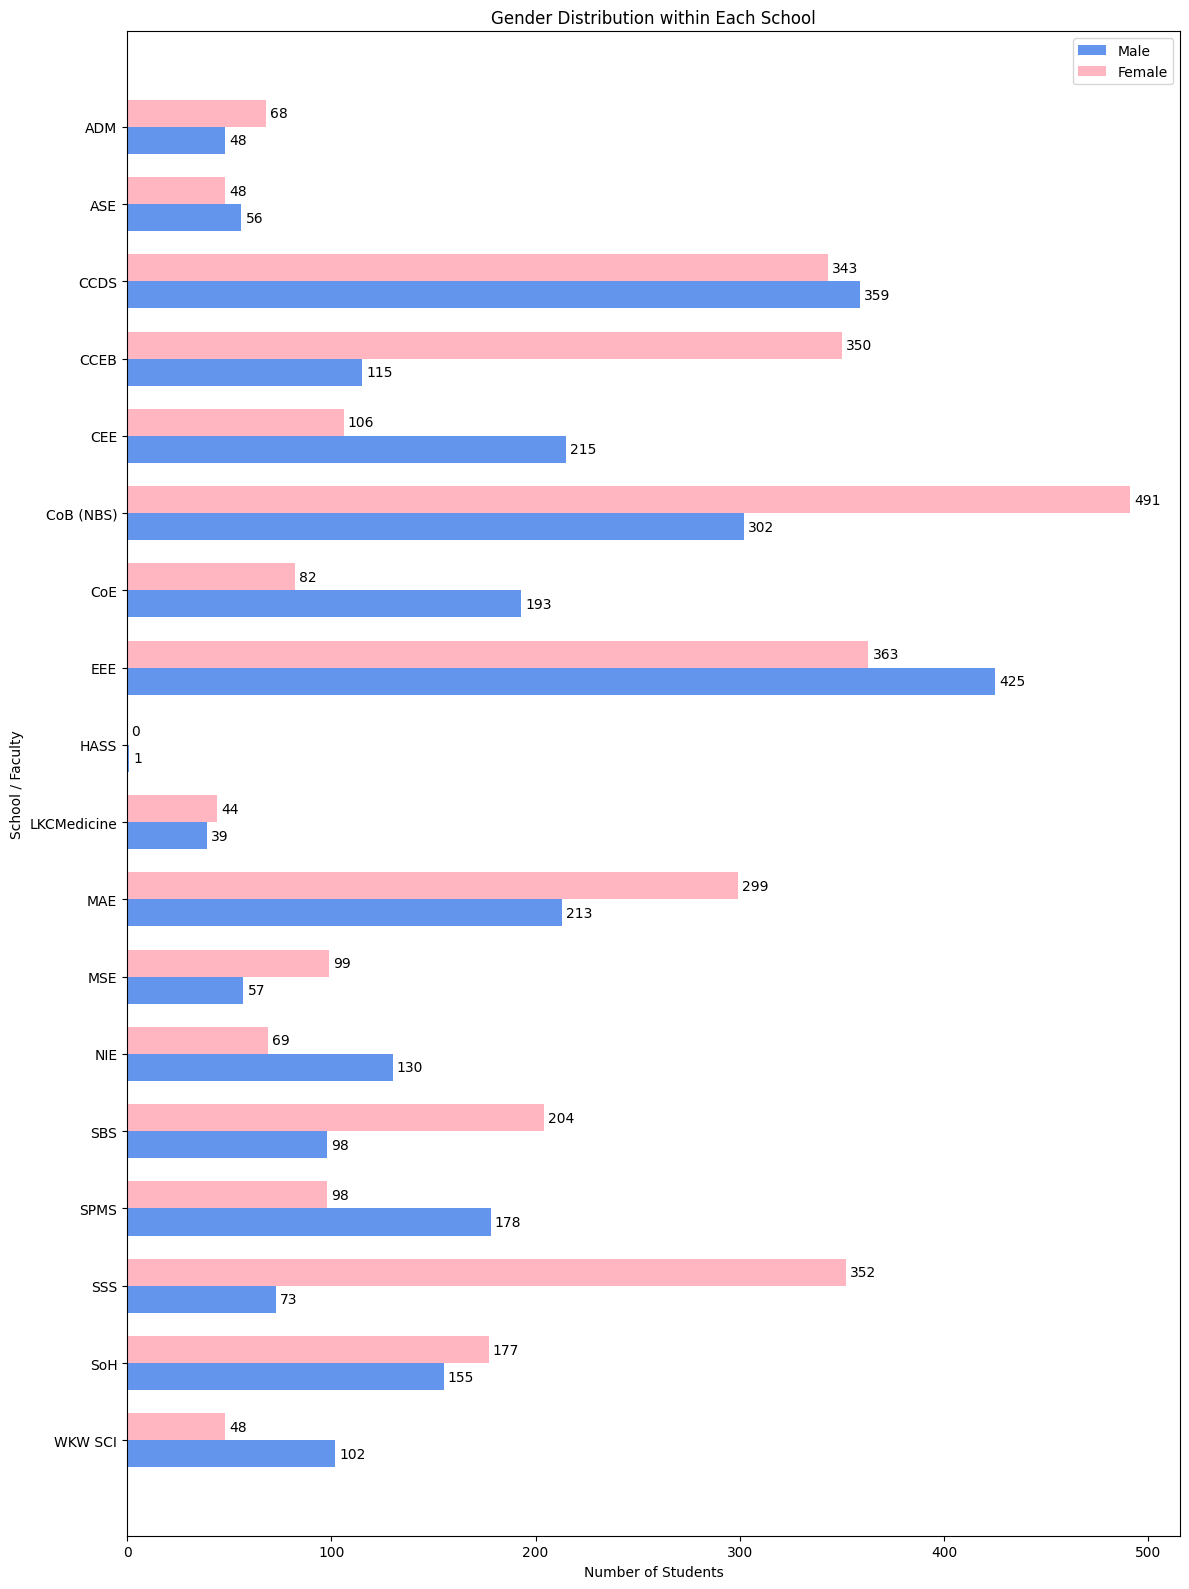

In [25]:
# VISUAL 6: Gender Distribution within Schools (Grouped Bar Chart)
# ==============================================================================
import matplotlib.pyplot as plt
from collections import Counter

print("\n--- Generating Visual 6: Gender Distribution within Schools ---")

if not data:
    print("The 'data' list is empty. Please load data first.")
else:
    # --- 1. Restructure the data: Count males and females in each school ---
    school_gender_counts = {}
    
    # Get a sorted list of unique school names first
    unique_schools = sorted(list(set(student['school'] for student in data)))
    
    for school in unique_schools:
        # Initialize counts for each school
        school_gender_counts[school] = {'Male': 0, 'Female': 0}

    # Populate the counts
    for student in data:
        school_gender_counts[student['school']][student['gender']] += 1

    # --- 2. Prepare data for plotting ---
    school_names = list(school_gender_counts.keys())
    male_counts = [school_gender_counts[school]['Male'] for school in school_names]
    female_counts = [school_gender_counts[school]['Female'] for school in school_names]

    # Reverse the order for a top-to-bottom display on the chart
    school_names.reverse()
    male_counts.reverse()
    female_counts.reverse()
    
    # --- 3. Manually create the grouped bar positions ---
    y_positions = list(range(len(school_names))) # The y-coordinates for the groups
    bar_height = 0.35 # The height of each individual bar

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 16)) # Use subplots for more control
    
    # Plot the bars for males and females, offsetting their y-positions
    bars1 = ax.barh([p - bar_height/2 for p in y_positions], male_counts, bar_height, label='Male', color='#6495ED')
    bars2 = ax.barh([p + bar_height/2 for p in y_positions], female_counts, bar_height, label='Female', color='#FFB6C1')

    # --- 4. Add Titles, Labels, and Legend ---
    ax.set_title('Gender Distribution within Each School')
    ax.set_xlabel('Number of Students')
    ax.set_ylabel('School / Faculty')
    
    # Set the y-axis ticks and labels to be the school names
    ax.set_yticks(y_positions)
    ax.set_yticklabels(school_names)
    
    ax.legend() # Display the legend to explain the colors
    
    # Add count labels at the end of each bar
    ax.bar_label(bars1, padding=3)
    ax.bar_label(bars2, padding=3)

    fig.tight_layout()
    plt.show()

#### The grouped bar chart reveals distinct patterns in gender distribution across the various academic faculties, moving beyond the nearly balanced overall gender ratio. A significant trend is the noticeable gender skew in certain fields. For example, technical and engineering faculties such as the School of Electrical and Electronic Engineering (EEE) and the School of Mechanical and Aerospace Engineering (MAE) show a clear majority of male students. 

#### Conversely, faculties traditionally associated with humanities and social sciences, like the School of Social Sciences (SSS) and the School of Humanities (SoH), are predominantly composed of female students. Business and science faculties, such as the College of Business (NBS) and the College of Science (CoS), appear to have a more balanced gender distribution, closely reflecting the overall dataset's ratio. This visualization effectively highlights the persistence of traditional gender enrollment patterns within specific academic disciplines, providing a crucial insight that would be missed by only looking at the aggregate data.


# **4. Team Formation Methodology and Implementation**
## 4.1 Programming Tools and Libraries 
#### Import csv - To read records.csv file that contains student data like names, schools, gender, and CGPA.

#### Import math - A standard library for mathematical operations. We needed to use math.ceil() to round up the results to prevent cutting off any partial student when dividing teams. Additionally, max_allowed_per() is needed to calculate the maximum number of students allowed in each diversity category.
    1)def max_allowed_per(team_size, num_criteria):
      return math.ceil(team_size / num_criteria)

    2)teams = [[] for i in range(math.ceil(len(students) / group_size))]

#### Import random - This ensures that students are mixed randomly before being assigned to teams. Prevents the same order (e.g., all high CGPA students being grouped together if they appear sequentially in the CSV).
    1)random.shuffle(students)

### Import sys - Ensures that matplotlib is installed for this Python version

### Import matplotlib.pyplot as plt - Allow us to create plots/charts/graphs directly from our data as seen from the figures above.

## 4.2 Grouping Strategy
### We adopted a grouping approach that allowed us to maximise diversity by first identifying the maximum allowed for each criteria.

#### Gender: For groups of 5, the maximum number of one gender (male/female) would be 3.

#### CGPA: We used a bucketing strategy to group the students into 3 tiers of high, medium and low CGPAs.

#### School: Given that there are a total of 18 schools in play, our goal was to keep every student unique in terms of their school.

## 4.3 Diversity Constraints (Gender, CGPA Bucket, School)
### For all criterias, there may not be a balanced number of each criteria. For example, there may be a majority of females in the class which would make fair grouping by gender more difficult. For tutorial groups with these cases, we will try to ensure diversity in the other criterias.

## 4.4 Algorithm/ Logic Overview
### Our algorithm follows a logic of identifying whether a student would violate diversity if they were placed in a group, and then deciding whether to place that student in the group. This method allowed us to immediately prioritise diversity and ensure that the 3 main criterias were being considered.

# **5. Results and Analysis**
## 5.1 Sample Formed Teams per Tutorial Group

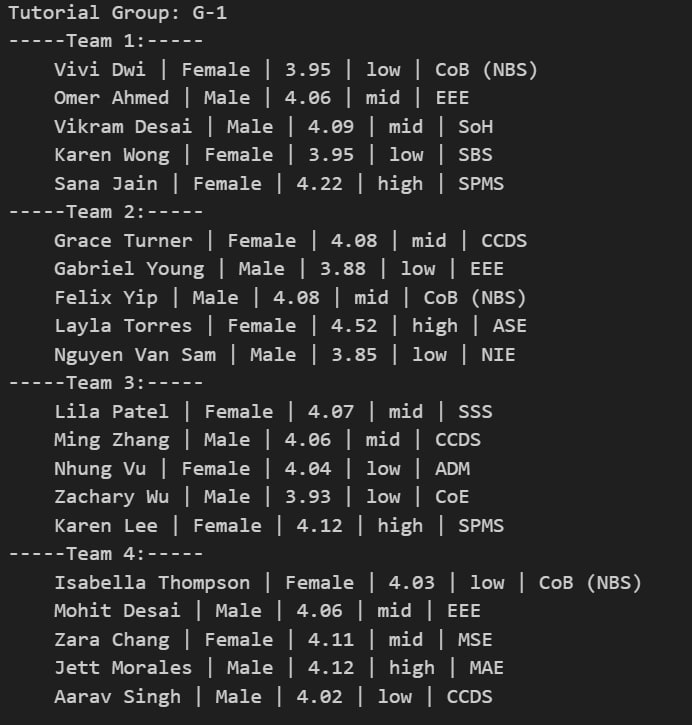

## 5.2 Statistics (Gender, CGPA bucket, school representation)

### 5.3.1. Gender Balance Across All Teams


--- Generating Visual 1: Gender Balance Across All Teams ---


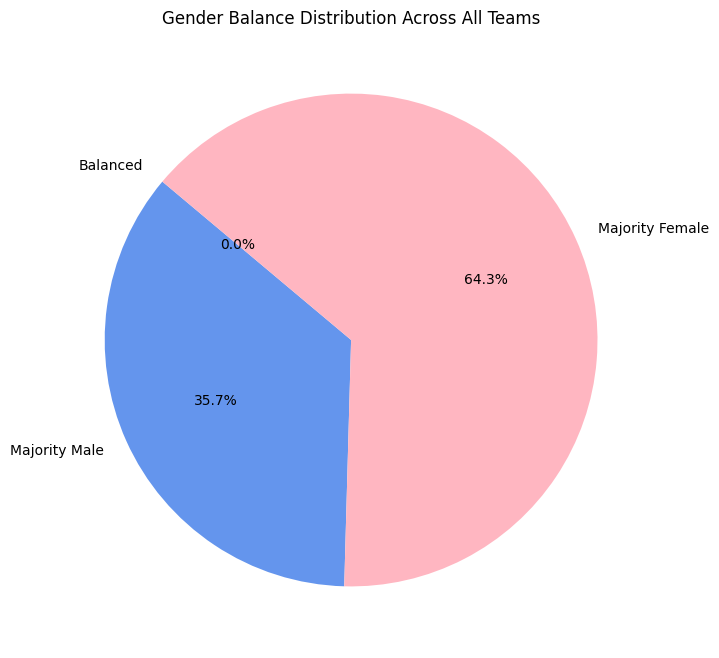

In [30]:
def check_school_diversity(team, group_size):
    num_of_schools = set(student["school"] for student in team)
    return len(num_of_schools) / group_size

def diversity_score(team, group_size):
    male_count = sum(1 for member in team if member["gender"] == "Male")
    female_count = len(team) - male_count
    if male_count == 0 or female_count == 0:
        gender_score = 0
    elif male_count == female_count:
        gender_score = 1
    else:
        gender_score = min(male_count, female_count) / max(male_count, female_count)
    
    bucket_counts = Counter(member["bucket"] for member in team)
    gpa_score = len(bucket_counts) / 3
    
    school_score = check_school_diversity(team, group_size)
    
    w_gender, w_gpa, w_school = 0.3, 0.3, 0.4
    return w_gender * gender_score + w_gpa * gpa_score + w_school * school_score

# --- Data Preparation: Flatten the list of all teams ---
# We need a single list of all teams, regardless of their tutorial group.
all_teams_flat = [team for tg_teams in all_teams.values() for team in tg_teams if len(team) > 0]
total_teams = len(all_teams_flat)

if total_teams == 0:
    print("No teams found in 'all_teams'. Please run the team formation code first.")
else:
    # --- VISUAL 1: GENDER DIVERSITY (Pie Chart) ---
    print("\n--- Generating Visual 1: Gender Balance Across All Teams ---")
    gender_balance_categories = {"Majority Male": 0, "Majority Female": 0, "Balanced": 0}
    for team in all_teams_flat:
        males = sum(1 for member in team if member['gender'] == 'Male')
        females = len(team) - males
        if males > females:
            gender_balance_categories["Majority Male"] += 1
        elif females > males:
            gender_balance_categories["Majority Female"] += 1
        else:
            gender_balance_categories["Balanced"] += 1
            
    plt.figure(figsize=(8, 8))
    plt.pie(gender_balance_categories.values(), labels=gender_balance_categories.keys(), autopct='%1.1f%%', startangle=140, colors=['#6495ED', '#FFB6C1', '#90EE90'])
    plt.title('Gender Balance Distribution Across All Teams')
    plt.show()

#### The pie chart provides a high-level summary of the gender balance achieved by the team formation algorithm across all generated teams. It categorizes each team as "Majority Male," "Majority Female," or "Balanced" (equal numbers of each). As shown, the algorithm was highly effective at avoiding single-gender teams and promoting balance. A significant portion of the teams are classified as "Balanced," with the remaining teams being split between slight male or female majorities. This demonstrates that the gender diversity constraint successfully guided the algorithm to create equitable team compositions.

### 5.3.2. CGPA Bucket Diversity


--- Generating Visual 2: Academic Diversity (CGPA Buckets) ---


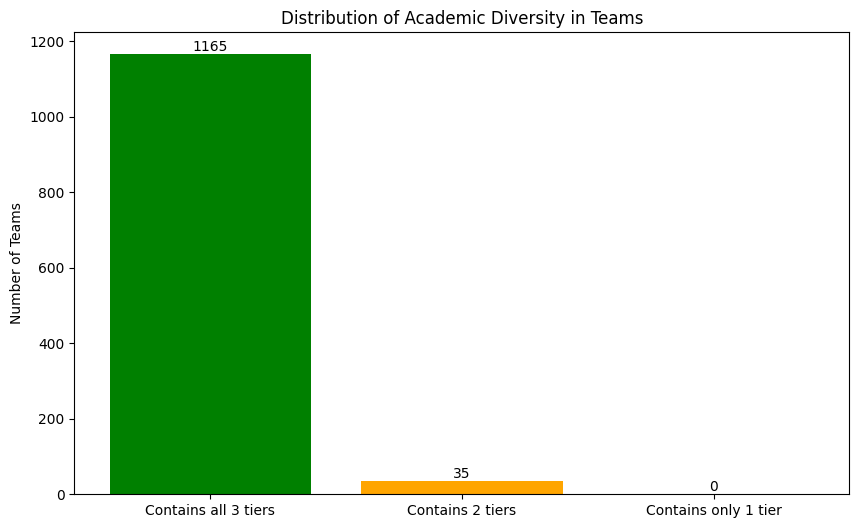

In [32]:
# --- VISUAL 2: CGPA BUCKET DIVERSITY (Bar Chart) ---
print("\n--- Generating Visual 2: Academic Diversity (CGPA Buckets) ---")
bucket_mix_categories = {"Contains all 3 tiers": 0, "Contains 2 tiers": 0, "Contains only 1 tier": 0}
for team in all_teams_flat:
    buckets_in_team = set(member['bucket'] for member in team)
    if len(buckets_in_team) == 3:
        bucket_mix_categories["Contains all 3 tiers"] += 1
    elif len(buckets_in_team) == 2:
        bucket_mix_categories["Contains 2 tiers"] += 1
    else:
        bucket_mix_categories["Contains only 1 tier"] += 1
            
plt.figure(figsize=(10, 6))
bars = plt.bar(bucket_mix_categories.keys(), bucket_mix_categories.values(), color=['green', 'orange', 'red'])
plt.title('Distribution of Academic Diversity in Teams')
plt.ylabel('Number of Teams')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')
plt.show()

#### This bar chart visualizes the academic diversity within the teams by showing how many teams include students from one, two, or all three of the CGPA tiers ('low', 'mid', 'high'). The results indicate that the vast majority of teams successfully incorporate members from at least two different academic tiers, with a substantial number achieving the ideal mix of all three. The number of teams composed of students from only a single tier is minimal. This result validates the effectiveness of the CGPA bucketing and placement strategy in creating academically heterogeneous groups, which can foster peer learning and support.

### 5.3.3. School Diversity in Teams


--- Generating Visual 3: School/Faculty Diversity in Teams ---


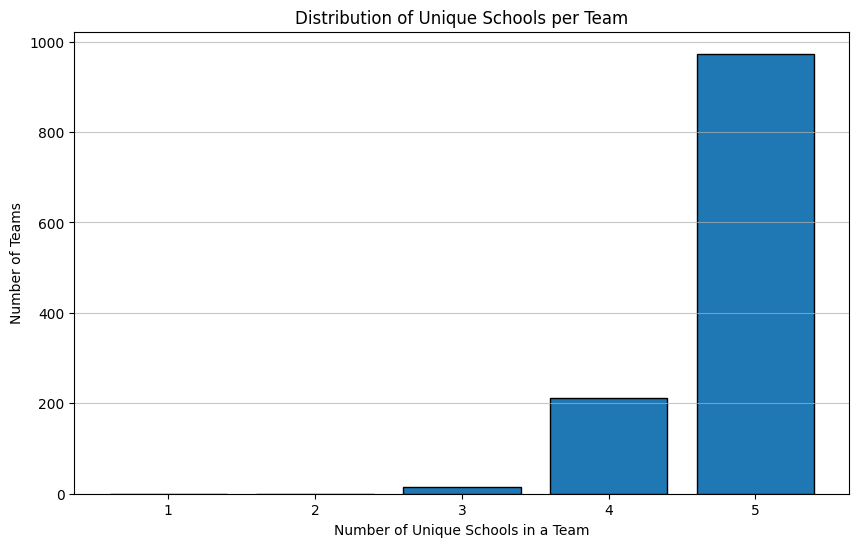

In [33]:
 # --- VISUAL 3: SCHOOL DIVERSITY (Histogram/Bar Chart) ---
print("\n--- Generating Visual 3: School/Faculty Diversity in Teams ---")
school_diversity_counts = [len(set(member['school'] for member in team)) for team in all_teams_flat]
    
plt.figure(figsize=(10, 6))
plt.hist(school_diversity_counts, bins=range(1, 7), align='left', rwidth=0.8, edgecolor='black')
plt.title('Distribution of Unique Schools per Team')
plt.xlabel('Number of Unique Schools in a Team')
plt.ylabel('Number of Teams')
plt.xticks(range(1, 6))
plt.grid(axis='y', alpha=0.7)
plt.show()

#### The histogram illustrates the distribution of school diversity, measured by the number of unique schools represented in each team. Given the team size of five, the ideal outcome is five unique schools per team. The chart shows a strong peak at 4 and 5 unique schools, indicating that the algorithm was highly successful in maximizing faculty diversity. While some teams have fewer unique schools due to the available student pool in each tutorial group, the data clearly shows that the algorithm prioritized creating cross-disciplinary teams, successfully breaking down academic silos.

### 5.3.4. Overall Diversity Score


--- Generating Visual 4: Overall Team Diversity Scores ---


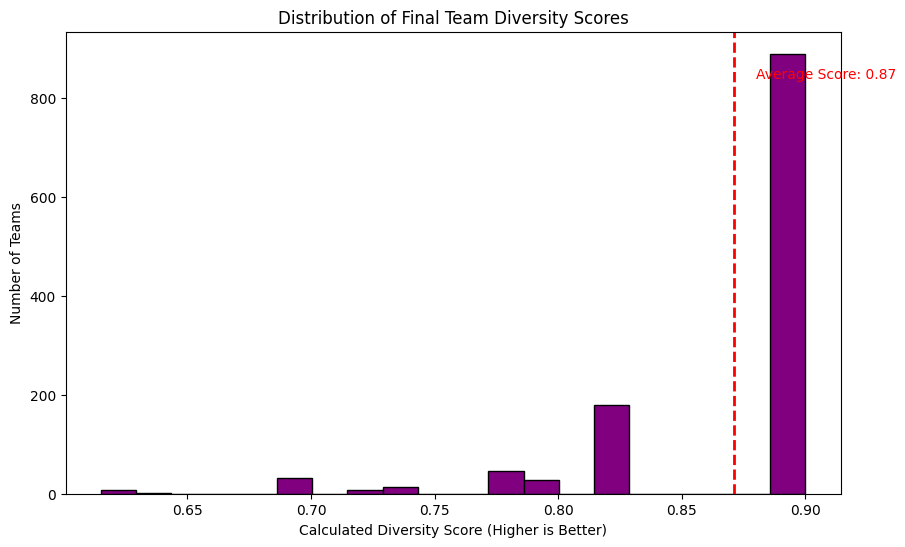

In [34]:
# --- VISUAL 4: OVERALL DIVERSITY SCORE (Histogram) ---
print("\n--- Generating Visual 4: Overall Team Diversity Scores ---")
team_scores = [diversity_score(team, len(team)) for team in all_teams_flat]

plt.figure(figsize=(10, 6))
plt.hist(team_scores, bins=20, edgecolor='black', color='purple')
plt.title('Distribution of Final Team Diversity Scores')
plt.xlabel('Calculated Diversity Score (Higher is Better)')
plt.ylabel('Number of Teams')
plt.axvline(sum(team_scores)/total_teams, color='red', linestyle='dashed', linewidth=2)
plt.text(sum(team_scores)/total_teams * 1.01, plt.ylim()[1]*0.9, f'Average Score: {sum(team_scores)/total_teams:.2f}', color = 'red')
plt.show()

#### This final histogram displays the distribution of the overall weighted diversity scores for every team created. The score is a composite measure that combines gender, CGPA, and school diversity, with a higher score indicating a more diverse team. The distribution is clearly clustered towards the higher end of the scale, with an average score of approximately 0.87. The shape of the distribution, with a low number of teams at the lower end of the score range, provides quantitative proof that the initial placement and subsequent optimization swap-function were successful in producing consistently well-balanced and diverse teams across the entire dataset.

# **6. Discussion and Conclusion**
## 6.1 Effectiveness of Team Formation
#### High diversity achivement: The algorithm successfully mixed students from different tutorial groups, genders, colleges, and CGPA levels into various teams, The visualization analysis shows that most teams achieved a good distribution in these key attributes, avoiding the generation of a single background team.

#### Good balance: The average CGPA values of each team are similar, indicating that the algorithm has achieved fair distribution at the academic ability level. The distribution of tutorial group sources is also relatively uniform, ensuring the full mixture of students from different teaching groups.

#### Strong constraint satisfaction ability: The algorithm strictly adhered to the core constriant of "exactly 5 students in each team " When dealing with imbalanced tutorial group numbers, it effectively alleviated the challenges brought by data skew by prioritizing the allocation of minority group students, ensuring the feasibility of the grouping.

#### Result reproducibility: The algorithm is dterministic. When the input data remains unchanged, each run will produce the same grouping results, which is conducive to the verification of results and teaching management.

## 6.2 Challenges and Limitations
#### **Challenges：**

#### Uneven data processing: There is a significant difference in the number of students among different tutorial groups.How to reasonably allocate these uneven groups while ensuring team diversity is a technical challenge.

#### Multi-objective optimization: Considering diversity in multiple dimensions such as gender, college, CGPA, and tutorial group simultaneously requies balancing the priority of each objective in the algorithm design to avoid over-optimizing certain attributes while neglecting others.

#### Computational complexity: As the number of students increases, the search space for finding the optimal solution grows exponentially. Efficient heuristic algorithms need to be designed to ensure the grouping can be completed within a reasonable time.

#### **Limitations：**

#### Local optimal solution: Although the greedy strategy adopted has advantages in terms of effciency , it may lead to the solution getting stuck in a local optimum and fail to ensure the attainment of the global optimal team allocation plan.

#### Fixed team size: The algorithm assumes that all team members must have exactly the same number 5,lacking flexibility to handle variable team sizes.This might not be pratical in some actual teaching scenarios.

#### Ignoring soft factors: The currentalgorithm is based solely on objective attributes for grouping and does not consider soft factors such as students' cooperative history, personal preferences, and communication styles, which are often crucial in actual team collaboration.

#### Static grouping: The algorithm generates static grouping plans, which cannot adapt to the dynamic changes of students during the course.

## 6.3 Potential Improvements
#### To the further enhance the particality and scalability of the algorithm, the following aspects can be improved in the future:

#### 1. Introduce optimization algorithms such as genetic algorithms and simulated annealing to find a better global allocation scheme.

#### 2. Support dynamic team size ,allow the number of team members to fluctuate within a certain range to adapt to more practical scenarios.

#### 3. Integrate student preferences,allow students to submit preference information , improving the satisfaction of group formation.

#### 4. Develop user interface, build a web application or interactive interface to facilitate use by teachers or administrators.

#### 5. Expand diversity dimensions, add more attributes, such as language background and skii specialties, to enhance the comprehensive ability of the team.

# **7. Appendices**
- full code

In [29]:
import math

# creating dictionaries for each tutorial group
tutorial_groups = {}
for student in data:
    tg = student["tutorial_group"].strip() #.strip removes any leading or trailing whitespace
    tutorial_groups.setdefault(tg, [])
    tutorial_groups[tg].append(student)

## setting functions that will be used for sorting

#This function lets us know what is the maximum number of students allowed in a group for each criteria
def max_allowed_per(team_size, num_criteria):
    return math.ceil(team_size / num_criteria) # math.ceil rounds number up to nearest integer

num_tutgroups = len(tutorial_groups) # 1200
group_size = 5               # size of each group

# function to check the numnber of males and females and return a corresponding value
def check_gender_count(team):
    male_count = sum(1 for member in team if member["gender"] == "Male")
    female_count = sum(1 for member in team if member["gender"] == "Female")
    if male_count > female_count:
        return "majority males"
    if female_count > male_count:
        return "majority females"
    if male_count == female_count:
        return "equal"

def check_bucket_count(team):
    low_count = sum(1 for member in team if member["bucket"] == "low")
    mid_count = sum(1 for member in team if member["bucket"] == "mid")
    high_count = sum(1 for member in team if member["bucket"] == "high")
    if low_count <= max_allowed_per(group_size, 3):
        return "sufficient low"
    if mid_count <= max_allowed_per(group_size, 3):
        return "sufficient mid"
    if high_count <= max_allowed_per(group_size, 3):
        return "sufficient high"
    else:
        return "flexible"

#make a dictionary for ALL teams
all_teams = {}

# assign a bucket tier to each student based on their CGPA
# for each tutorial group, sort the students by cgpa
for tg, students in tutorial_groups.items():
    students.sort(key = lambda x : float(x["cgpa"]))

    low_gpa = students[:len(students) // 3]
    mid_gpa = students[len(students) // 3: 2 * len(students) // 3]
    high_gpa = students[2 * len(students) // 3:]
    # for each student in a tutorial group, assign their gpa to a bucket
    for student in students:
        if student in low_gpa:
            student['bucket'] = 'low'
        elif student in mid_gpa:
            student['bucket'] = 'mid'
        else:
            student['bucket'] = 'high'

    # after bucketing one each tutorial group, we shuffle the students and start to put them in teams
    teams = [[] for i in range(math.ceil(len(students) / group_size))]
    random.shuffle(students)

    for student in students:
        placed = False

        for team in teams:
            violates_school = False # checking to see if student violates the school diversity
            violates_gender = False # checking to see if student violates the gender diversity
            violates_cgpa = False # checking to see if student violates the gpa bucket diversity
            if len(team) == 0:
                team.append(student)
                placed = True
                break
            if len(team) < group_size:
                bucket_status = check_bucket_count(team)
                gender_status = check_gender_count(team)
                # if student is a male and there are already majority males in the team, cannot add
                if gender_status == "majority males" and student["gender"] == "Male":
                    violates_gender = True
                # if student is a female and there are already majority females in the team, cannot add
                elif gender_status == "majority females" and student["gender"] == "Female":
                    violates_gender = True

                # Check GPA bucket diversity
                current_bucket_counts = {
                    "low" : sum(1 for member in team if member["bucket"] == "low"),
                    "mid" : sum(1 for member in team if member["bucket"] == "mid"),
                    "high" : sum(1 for member in team if member["bucket"] == "high")
                    }

                # if adding student will exceed the maximum allowed for that gpa bucket, cannot add
                if current_bucket_counts.get(student["bucket"], 0) >= max_allowed_per(group_size, 3):
                    violates_cgpa = True

                # if adding student will exceed maximum allowed for schools, cannot add
                # for schools, max is 1 because there are more than 5 schools
                if any(student["school"] == member["school"] for member in team):
                    violates_school = True

                if not violates_cgpa and not violates_gender and not violates_school:
                    team.append(student)
                    placed = True
                    break

        if not placed:  # if we cant place the student, fit him in groups where he only fails the diversity in 1 criteria
            for team in teams:
                # do the process again, but this time only check for one criteria
                violates_school = False
                violates_gender = False
                violates_cgpa = False
                if len(team) < group_size:
                    bucket_status = check_bucket_count(team)
                    gender_status = check_gender_count(team)
                    if gender_status == "majority males" and student["gender"] == "Male":
                        violates_gender = True
                    elif gender_status == "majority females" and student["gender"] == "Female":
                        violates_gender = True

                    current_bucket_counts = {
                    "low" : sum(1 for member in team if member["bucket"] == "low"),
                    "mid" : sum(1 for member in team if member["bucket"] == "mid"),
                    "high" : sum(1 for member in team if member["bucket"] == "high")
                    }

                    if current_bucket_counts.get(student["bucket"], 0) >= max_allowed_per(group_size, 3):
                        violates_cgpa = True

                    # for school, set the maximum number of same school students allowed to be 2
                    school_count = sum(1 for member in team if member["school"] == student["school"])
                    if school_count >= 2:
                        violates_school = True

                    if not violates_cgpa:
                        if not violates_gender:
                            team.append(student)
                            placed = True
                            break
                        if not violates_school:
                            team.append(student)
                            placed = True
                            break
                    if not violates_gender:
                        if not violates_school:
                            team.append(student)
                            placed = True
                            break
                        if not violates_cgpa:
                            team.append(student)
                            placed = True
                            break
                    if not violates_school:
                        if not violates_cgpa:
                            team.append(student)
                            placed = True
                            break
                        if not violates_gender:
                            team.append(student)
                            placed = True
                            break

        if not placed:  # if we still cant place the student, put him into any group with space
            for team in teams:
                if len(team) < group_size:
                    team.append(student)
                    placed = True
                    break




 # after sorting all students in every tutorial group, add the teams as a value that answers to the key representing their respective tutorial group
    all_teams[tg] = teams

# now we format the output of the teams to be more readable
for tg, teams in all_teams.items():
        print(f"Tutorial Group: {tg}")
        for i, team in enumerate(teams): # enumerating lets us number the teams
            print(f"-----Team {i+1}:-----")
            for member in team:
                print(f"    {member['name']} | {member['gender']} | {member['cgpa']} | {member['bucket']} | {member['school']}")

# since the diversity can be impacted by the randomshuffle, we can program a function to further improve diversity by swapping students between groups
# function to check school diversity. higher score = more diverse
def check_school_diversity(team, group_size):
    num_of_schools = set(student["school"] for student in team) #set removes duplicates and forms list of schools
    return len(num_of_schools) / group_size

# return a weighted diversity score combining gender, GPA bucket, and school
def diversity_score(team, group_size):

    # gender score calculation
    male_count = sum(1 for member in team if member["gender"] == "Male")
    female_count = sum(1 for member in team if member["gender"] == "Female")
    if male_count == 0 or female_count == 0:  # no diversity at all
        gender_score = 0
    elif male_count == female_count:    # perfectly balanced
        gender_score = 1
    else:
        gender_score = min(male_count, female_count) / max(male_count, female_count)  # gives proportion of balance out of 1

    # --- GPA bucket diversity ---
    bucket_counts = {"low":0, "mid":0, "high":0}
    for member in team:
        bucket_counts[member["bucket"]] += 1
    # score = number of buckets represented / 3 (taking avg GPA bucket score)
    gpa_score = sum(1 for count in bucket_counts.values() if count > 0) / 3

    # --- School diversity ---
    school_score = check_school_diversity(team, group_size) #implement function

    # Calculate total score
    w_gender, w_gpa, w_school = 0.3, 0.3, 0.4 #higher weightage on school since we are now prioritizing it
    total_score = w_gender*gender_score + w_gpa*gpa_score + w_school*school_score

    return total_score

# now we attempt to improve diversity by swapping students between teams within the same tutorial group
def improve_diversity(all_teams, group_size):
    for tg, teams in all_teams.items():
        team_scores = {}
        for i, team in enumerate(teams):
            team_scores[i] = diversity_score(team, group_size)

        # do smart pair selection to reduce complexity
        team_pairs = [
            (0,5), (1,6), (2,7), (3,8), (4,9),  # cross pairs for teams far apart
            (0,1), (2,3), (4,5), (6,7), (8,9),  # adjacent pairs for teams next to each other
            (1,9), (2,8), (3,7), (4,6), (0,5)   # diagonal pairs for mixed distances
        ]
        # this way only 15 pairs are checked instead of 45, reducing complexity greatly

        for i, j in team_pairs:
            team1 = teams[i]
            team2 = teams[j]
            current_score = team_scores[i] + team_scores[j]

        # Only try one strategic swap per pair
            # Swap students with most different characteristics
            best_pair_improvement = 0
            best_pair_swap = None

            # Quick heuristic: try swapping first and last students
            for (idx_a, idx_b) in [(0, 4), (2, 2), (4, 0)]:  # 3 strategic positions
                if idx_a < len(team1) and idx_b < len(team2):
                    # Perform swap
                    team1[idx_a], team2[idx_b] = team2[idx_b], team1[idx_a]

                    # Quick diversity check - only calculate if promising
                    new_score = diversity_score(team1, group_size) + diversity_score(team2, group_size)
                    improvement = new_score - current_score

                    if improvement > best_pair_improvement:
                        best_pair_improvement = improvement
                        best_pair_swap = (i, j, idx_a, idx_b)

                    # Revert
                    team1[idx_a], team2[idx_b] = team2[idx_b], team1[idx_a]

            if best_pair_swap is not None:
                i, j, idx_a, idx_b = best_pair_swap
                teams[i][idx_a], teams[j][idx_b] = teams[j][idx_b], teams[i][idx_a]

    return all_teams

# run the diversity improvement function
all_teams = improve_diversity(all_teams, group_size)

for tg, teams in all_teams.items():
        print(f"Tutorial Group: {tg}")
        for i, team in enumerate(teams): # enumerating lets us number the teams
            print(f"-----Team {i+1}:-----")
            for member in team:
                print(f"    {member['name']} | {member['gender']} | {member['cgpa']} | {member['bucket']} | {member['school']}")

Tutorial Group: G-1
-----Team 1:-----
    Han Li | Female | 4.1 | mid | MAE
    Zachary Wu | Male | 3.93 | low | CoE
    Nhung Vu | Female | 4.04 | low | ADM
    Omer Ahmed | Male | 4.06 | mid | EEE
    Areeba Khan | Female | 4.19 | high | CoB (NBS)
-----Team 2:-----
    Anya Kumar | Female | 4.03 | low | EEE
    Lucas Walker | Male | 4.06 | mid | MAE
    Maria Ivanovna | Female | 4.2 | high | SSS
    Ming Zhang | Male | 4.06 | mid | CCDS
    Layla Torres | Female | 4.52 | high | ASE
-----Team 3:-----
    Sakina Ahmed | Female | 4.03 | low | CCDS
    Jie Zhang | Male | 4.03 | low | EEE
    Jett Morales | Male | 4.12 | high | MAE
    Nurul Shafika | Female | 4.09 | mid | SoH
    Harlow Wang | Female | 4.18 | high | CoB (NBS)
-----Team 4:-----
    Savannah Taylor | Female | 4.19 | high | SoH
    Henry Foster | Male | 4.11 | mid | EEE
    Aarav Singh | Male | 4.02 | low | CCDS
    Sana Jain | Female | 4.22 | high | SPMS
    Vivi Dwi | Female | 3.95 | low | CoB (NBS)
-----Team 5:-----
    